# Arquitetura de Dados — Evolução Temporal das Contratações Públicas

## Introdução

Neste projeto é apresentado uma análise descritiva da evolução temporal das contratações públicas relacionadas a obras, construção e serviços de engenharia no Estado de São Paulo. O estudo considera o primeiro semestre dos anos de 2023, 2024, 2025 e 2026, utilizando dados disponibilizados pelo Portal Nacional de Contratações Públicas (PNCP) por meio de sua API de Dados Abertos.

A análise busca transformar os registros brutos de contratações em informações comparáveis ao longo do tempo, observando tanto a quantidade de contratações quanto os valores homologados. Além da comparação anual, o estudo considera a distribuição mensal das contratações e realiza procedimentos de validação, deduplicação e tratamento de uma observação identificada como anômala.

A importância deste estudo está na possibilidade de observar, de forma organizada e reprodutível, como o volume e os valores das contratações públicas se comportam em diferentes períodos. A comparação entre anos eleitorais e não eleitorais é utilizada apenas como uma forma de organização descritiva dos dados, não permitindo, por si só, afirmar que uma variação observada foi causada pelo período eleitoral.

#### **Pergunta Norteadora**

Como evoluíram a quantidade e os valores das contratações públicas de obras, construção e serviços de engenharia no Estado de São Paulo durante o primeiro semestre de 2023 a 2026, e quais diferenças descritivas podem ser observadas entre os anos eleitorais e não eleitorais?

#### **Objetivo:** 

Analisar, de forma descritiva, a quantidade e os valores das contratações públicas relacionadas a obras, construção e serviços de engenharia no Estado de São Paulo, considerando o primeiro semestre de 2023 a 2026.

> **Importante:** 2024 é classificado como ano de eleição municipal e 2026 como ano de eleição geral. A classificação não implica causalidade; ela apenas organiza a comparação descritiva.


## Bloco 1: Fonte, escopo e reprodutibilidade

- **Fonte:** Portal Nacional de Contratações Públicas (PNCP), via API de Dados Abertos.
- **Endpoint utilizado:** `modulo-contratacoes/1_consultarContratacoes_PNCP_14133`.
- **UF:** SP.
- **Período:** 1º de janeiro a 30 de junho de cada ano.
- **Anos:** 2023, 2024, 2025 e 2026.
- **Modalidade informada na consulta:** código 6.
- **Paginação:** 500 registros por página, até a resposta sem registros.

Neste bloco foram definidos os parâmetros que tornam a coleta reproduzível: endereço da API, endpoint, anos analisados, tamanho das páginas, código da modalidade e unidade federativa. A configuração centraliza os parâmetros da consulta e facilita a repetição da análise em uma nova execução.

In [5]:
#%pip install requests pandas matplotlib seaborn -q
#%pip install seaborn -q

In [6]:
import re
import time
import unicodedata
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests

sns.set_theme(style="whitegrid")

print("Execução:", datetime.now().strftime("%d/%m/%Y %H:%M:%S"))

Execução: 30/09/2026 15:44:28


In [7]:
# Configuração da API
BASE_URL = "https://dadosabertos.compras.gov.br"
ENDPOINT_CONTRATACOES = "/modulo-contratacoes/1_consultarContratacoes_PNCP_14133"
URL = BASE_URL + ENDPOINT_CONTRATACOES

ANOS = [2023, 2024, 2025, 2026]
TAMANHO_PAGINA = 500
CODIGO_MODALIDADE = 6
UF = "SP"

print("Endpoint:", URL)
print("Parâmetros fixos:", {
    "codigoModalidade": CODIGO_MODALIDADE,
    "unidadeOrgaoUfSigla": UF,
    "tamanhoPagina": TAMANHO_PAGINA
})

Endpoint: https://dadosabertos.compras.gov.br/modulo-contratacoes/1_consultarContratacoes_PNCP_14133
Parâmetros fixos: {'codigoModalidade': 6, 'unidadeOrgaoUfSigla': 'SP', 'tamanhoPagina': 500}


## Bloco 2: Função auxiliar de extração

Foi criada uma função auxiliar para lidar com diferentes formatos possíveis de resposta JSON da API. A função procura as estruturas mais comuns que podem conter a lista de registros e retorna uma lista padronizada para as etapas seguintes. Isso torna a extração mais robusta sem alterar o conteúdo dos registros recebidos.

In [8]:
def extrair_registros(json_resposta):
    """Extrai a lista de registros de diferentes estruturas possíveis da resposta JSON."""
    if isinstance(json_resposta, list):
        return json_resposta
    if not isinstance(json_resposta, dict):
        return []
    for chave in ["resultado", "resultados", "data", "content"]:
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave]
    return []

## Bloco 3: Coleta automática com paginação

A coleta é realizada automaticamente para cada ano, considerando o período de 1º de janeiro a 30 de junho. Para cada ano, o código percorre as páginas da API até encontrar uma resposta sem registros, armazena os dados obtidos e registra um resumo com a quantidade de registros e páginas consultadas.

Esse procedimento evita depender de uma consulta manual e permite reproduzir a coleta para todo o período estudado.

In [9]:
todos_registros = []
resumo_coleta = []
sessao = requests.Session()

for ano in ANOS:
    data_inicio = f"{ano}-01-01"
    data_fim = f"{ano}-06-30"
    pagina = 1
    registros_ano = 0

    print(f"\n--- Coletando 1º semestre de {ano} ({data_inicio} a {data_fim}) ---")

    while True:
        params = {
            "pagina": pagina,
            "tamanhoPagina": TAMANHO_PAGINA,
            "dataPublicacaoPncpInicial": data_inicio,
            "dataPublicacaoPncpFinal": data_fim,
            "codigoModalidade": CODIGO_MODALIDADE,
            "unidadeOrgaoUfSigla": UF
        }

        try:
            resposta = sessao.get(URL, params=params, timeout=60)
            resposta.raise_for_status()
            registros_pagina = extrair_registros(resposta.json())

            if not registros_pagina:
                break

            todos_registros.extend(registros_pagina)
            registros_ano += len(registros_pagina)
            pagina += 1
            time.sleep(0.3)

        except requests.RequestException as erro:
            print(f"Erro na coleta de {ano}, página {pagina}: {erro}")
            break

    resumo_coleta.append({
        "ano": ano,
        "data_inicio": data_inicio,
        "data_fim": data_fim,
        "registros_coletados": registros_ano,
        "paginas_consultadas": pagina - 1
    })
    print(f"Registros coletados em {ano}: {registros_ano:,}")

resumo_coleta = pd.DataFrame(resumo_coleta)
print(f"\nTotal bruto de registros coletados: {len(todos_registros):,}")
display(resumo_coleta)


--- Coletando 1º semestre de 2023 (2023-01-01 a 2023-06-30) ---
Registros coletados em 2023: 4,108

--- Coletando 1º semestre de 2024 (2024-01-01 a 2024-06-30) ---
Registros coletados em 2024: 13,051

--- Coletando 1º semestre de 2025 (2025-01-01 a 2025-06-30) ---
Registros coletados em 2025: 15,231

--- Coletando 1º semestre de 2026 (2026-01-01 a 2026-06-30) ---
Registros coletados em 2026: 14,992

Total bruto de registros coletados: 47,382


,ano,data_inicio,data_fim,registros_coletados,paginas_consultadas
0,2023,2023-01-01,2023-06-30,4108,9
1,2024,2024-01-01,2024-06-30,13051,27
2,2025,2025-01-01,2025-06-30,15231,31
3,2026,2026-01-01,2026-06-30,14992,30


## Bloco 4: Normalização, validação e filtro temático

A busca temática é feita sobre `objetoCompra`, com normalização de caixa e remoção de acentos. As palavras são buscadas em forma flexível, permitindo flexões simples como `obra/obras`, sem depender da forma exata do acento.

Depois da aplicação do filtro temático, foi realizada uma verificação manual rápida dos objetos de compra encontrados por cada termo. A finalidade é conferir se as palavras-chave estão capturando registros coerentes com o tema do estudo e identificar possíveis falsos positivos antes da análise agregada.

In [10]:
df_raw = pd.json_normalize(todos_registros)

colunas_interesse = [
    'idCompra', 'numeroControlePNCP', 'anoCompraPncp', 'dataPublicacaoPncp',
    'orgaoEntidadeRazaoSocial', 'orgaoEntidadeEsferaId',
    'unidadeOrgaoMunicipioNome', 'unidadeOrgaoUfSigla', 'modalidadeNome',
    'situacaoCompraNomePncp', 'objetoCompra', 'valorTotalEstimado',
    'valorTotalHomologado'
]

colunas_presentes = [c for c in colunas_interesse if c in df_raw.columns]
df = df_raw[colunas_presentes].copy()

# Tipos
df['idCompra'] = (
    df['idCompra'].astype('string').str.replace(r'\.0$', '', regex=True)
)
df['objetoCompra'] = df['objetoCompra'].astype('string')
df['situacaoCompraNomePncp'] = df['situacaoCompraNomePncp'].astype('string')
df['valorTotalEstimado'] = pd.to_numeric(df['valorTotalEstimado'], errors='coerce')
df['valorTotalHomologado'] = pd.to_numeric(df['valorTotalHomologado'], errors='coerce')
df['dataPublicacaoPncp'] = pd.to_datetime(df['dataPublicacaoPncp'], errors='coerce')
df['ano'] = df['dataPublicacaoPncp'].dt.year

# Diagnóstico de qualidade antes do filtro temático
diagnostico = pd.DataFrame({
    'indicador': [
        'Registros brutos',
        'ID ausente',
        'Data de publicação inválida/ausente',
        'Valor homologado nulo',
        'Valor homologado igual a zero',
        'Valor homologado negativo'
    ],
    'quantidade': [
        len(df),
        df['idCompra'].isna().sum(),
        df['dataPublicacaoPncp'].isna().sum(),
        df['valorTotalHomologado'].isna().sum(),
        (df['valorTotalHomologado'] == 0).sum(),
        (df['valorTotalHomologado'] < 0).sum()
    ]
})
print('=== Diagnóstico inicial ===')
display(diagnostico)

=== Diagnóstico inicial ===


,indicador,quantidade
0,Registros brutos,47382
1,ID ausente,0
2,Data de publicação inválida/ausente,0
3,Valor homologado nulo,5749
4,Valor homologado igual a zero,1
5,Valor homologado negativo,0


In [11]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    return texto

df['objeto_normalizado'] = df['objetoCompra'].map(normalizar_texto)

# Termos definidos para representar o escopo temático do estudo.
palavras_chave = [
    'obra',
    'construcao',
    'engenharia',
    'arquitetura',
    'reforma',
    'pavimentacao'
]

# Busca de flexões simples: obra/obras, reforma/reformas etc.
termo_regex = {
    termo: rf'\b{re.escape(termo)}\w*'
    for termo in palavras_chave
}

mascara_tematica = pd.Series(False, index=df.index)
for termo, regex in termo_regex.items():
    mascara_tematica |= df['objeto_normalizado'].str.contains(regex, regex=True, na=False)

df_filtrado = df.loc[mascara_tematica].copy()

# Diagnóstico por termo: útil para validar o filtro no relatório.
linhas_termos = []
for termo, regex in termo_regex.items():
    mascara = df['objeto_normalizado'].str.contains(regex, regex=True, na=False)
    linhas_termos.append({
        'termo': termo,
        'registros_encontrados': int(mascara.sum())
    })

resumo_termos = pd.DataFrame(linhas_termos)
print('=== Registros encontrados por termo ===')
display(resumo_termos)
print(f"Registros após o filtro temático: {len(df_filtrado):,}")

=== Registros encontrados por termo ===


,termo,registros_encontrados
0,obra,975
1,construcao,280
2,engenharia,405
3,arquitetura,53
4,reforma,342
5,pavimentacao,11


Registros após o filtro temático: 1,866


In [12]:
# Validação manual rápida do filtro: amostra dos objetos encontrados por termo.
for termo, regex in termo_regex.items():
    amostra = (
        df.loc[
            df['objeto_normalizado'].str.contains(regex, regex=True, na=False),
            ['idCompra', 'objetoCompra']
        ]
        .drop_duplicates()
        .head(5)
    )
    print(f"\n=== Exemplos para '{termo}' ===")
    display(amostra)


=== Exemplos para 'obra' ===


,idCompra,objetoCompra
24,37306606000022023,Contratação dos serviços continuados de copeir...
87,92606506000032023,MANUTENÇÃO CORRETIVA - A SER REALIZADA NO VEÍC...
101,98630906000412023,"Recapagem de pneu 1400x24, pertencentes a maqu..."
107,92606506002092022,Contratação de empresa especializada na presta...
168,98630906000692023,Serviço de mão de obra com material incluso pa...



=== Exemplos para 'construcao' ===


,idCompra,objetoCompra
174,98694906000032023,Contratação de empresa especializada para a ex...
343,98618106000012023,Contratação de empresa sob regime de empreitad...
536,98696906000662023,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA PARA FORN...
554,98630906001132023,Aquisição de materiais de construção para manu...
583,16048006000092023,Aquisição de Material de Construção.



=== Exemplos para 'engenharia' ===


...

,idCompra,objetoCompra
589,92865706000012023,"Licença Windows Server 2022 Standart Edition, ..."
844,92650706000032023,Aquisição e instalação de dois aparelhos de ar...
1139,92500306000542023,CONTRATAÇÃO DE EMPRESA DE ENGENHARIA OU ARQUIT...
1843,92650706000132023,Contratação de empresa para prestação de servi...
2285,17013806000052023,Contratação de pessoa jurídica especializada p...



=== Exemplos para 'reforma' ===


,idCompra,objetoCompra
100,98630906000442023,"Aquisição de cimento, para utilização na refor..."
237,92509306000092023,Aquisição de Madeiras PARA UTILIZAÇÃO COMO FOR...
432,24003106000192023,Serviço para reforma/adaptação técnica de espa...
433,24003106000202023,Reforma de sofá da recepção do ERESP
805,92507606000022023,Reforma da Praça Sônia Aparecida Peixoto - Vil...



=== Exemplos para 'pavimentacao' ===


,idCompra,objetoCompra
8191,92507606900072024,"Aquisição de Asfalto a Frio para Pavimentação,..."
8354,92505806000212024,"INTERVENÇÃO EM CARÁTER EMERGENCIAL, PARA REALI..."
8805,92506506900112024,OBJETO: CONTRATAÇÃO DE READEQUAÇÃO DE PAVIMENT...
9188,92506506900132024,READEQUAÇÃO DE PAVIMENTAÇÃO ASFALTICA / LOCAL:...
17724,38011906000412025,Aquisição de 60m³ de Pedra Brita nº 2 para ser...


## Bloco 5: Critérios de qualidade, status e deduplicação

- Registros sem `idCompra` ou sem data válida não conseguem ser identificados/reconciliados na unidade temporal e são retirados da base analítica, sendo contabilizados no diagnóstico.
- Valores homologados nulos não são considerados nas estatísticas financeiras que usam `mean`, `median` e soma; eles permanecem na contagem de contratações.
- Valores homologados iguais a zero **não são removidos automaticamente**: o zero informado pela fonte é preservado e quantificado separadamente.
- Registros com situação de cancelamento são identificados para auditoria; este notebook não os remove automaticamente sem uma regra adicional definida pela equipe.
- Duplicidades são tratadas por `idCompra`, mantendo uma única observação por contratação antes de qualquer agregação.

In [13]:
# Validação mínima da unidade de análise
df_filtrado = df_filtrado.loc[
    df_filtrado['idCompra'].notna() & df_filtrado['dataPublicacaoPncp'].notna()
].copy()

# Classificação eleitoral: 2024 = municipal; 2026 = geral.
mapa_ano = {
    2023: ('Não eleitoral', 'Não eleitoral'),
    2024: ('Eleitoral', 'Eleição municipal'),
    2025: ('Não eleitoral', 'Não eleitoral'),
    2026: ('Eleitoral', 'Eleição geral')
}

df_filtrado['Tipo_Ano'] = df_filtrado['ano'].map(lambda x: mapa_ano.get(x, ('Indefinido', 'Indefinido'))[0])
df_filtrado['Tipo_Eleicao'] = df_filtrado['ano'].map(lambda x: mapa_ano.get(x, ('Indefinido', 'Indefinido'))[1])

# Auditoria da deduplicação
qtd_antes = len(df_filtrado)
df_unicos = (
    df_filtrado
    .sort_values(['idCompra', 'dataPublicacaoPncp'])
    .drop_duplicates(subset='idCompra', keep='first')
    .copy()
)
qtd_depois = len(df_unicos)

print(f"Registros no escopo após validação básica: {qtd_antes:,}")
print(f"Contratações únicas após deduplicação: {qtd_depois:,}")
print(f"Registros removidos na deduplicação: {qtd_antes - qtd_depois:,}")

# Cancelamentos: apenas diagnóstico, sem exclusão automática.
status_normalizado = df_unicos['situacaoCompraNomePncp'].fillna('').map(normalizar_texto)
df_unicos['eh_cancelada'] = status_normalizado.str.contains('cancelad', na=False)
print(f"Contratações marcadas como canceladas: {df_unicos['eh_cancelada'].sum():,}")

Registros no escopo após validação básica: 1,866
Contratações únicas após deduplicação: 1,853
Registros removidos na deduplicação: 13
Contratações marcadas como canceladas: 0


## Bloco 6: Registro anômalo e análise de sensibilidade

Foi isolado um registro identificado como anômalo, de aproximadamente R$ 108 bilhões, para evitar que uma única observação de magnitude muito superior às demais distorcesse a leitura das métricas agregadas.

A estratégia adotada não consiste em estabelecer um limite arbitrário de valor. A exclusão é feita pelo `idCompra` específico, mantendo também uma versão da base com o registro para permitir a análise de sensibilidade e comparar os resultados com e sem a anomalia.

In [14]:
ID_COMPRA_ANOMALA = '99003506000602026'

anomalia = df_unicos.loc[df_unicos['idCompra'].eq(ID_COMPRA_ANOMALA)].copy()

print('=== Registro identificado como anômalo ===')
if anomalia.empty:
    print('ATENÇÃO: o ID da anomalia não foi localizado na base atual.')
else:
    display(anomalia[[
        'idCompra', 'ano', 'orgaoEntidadeRazaoSocial',
        'unidadeOrgaoMunicipioNome', 'objetoCompra',
        'valorTotalHomologado', 'situacaoCompraNomePncp'
    ]].style.format({'valorTotalHomologado': lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.') if pd.notna(x) else ''}))

df_completa = df_unicos.copy()
df_analise = df_unicos.loc[~df_unicos['idCompra'].eq(ID_COMPRA_ANOMALA)].copy()

print(f"Contratações únicas com o registro: {df_completa['idCompra'].nunique():,}")
print(f"Contratações únicas sem o registro: {df_analise['idCompra'].nunique():,}")
print('Anomalia presente em df_analise?', df_analise['idCompra'].eq(ID_COMPRA_ANOMALA).any())

=== Registro identificado como anômalo ===


,idCompra,ano,orgaoEntidadeRazaoSocial,unidadeOrgaoMunicipioNome,objetoCompra,valorTotalHomologado,situacaoCompraNomePncp
39051,99003506000602026,2026,SECRETARIA DE GOVERNO,SÃO PAULO,"O presente instrumento é a contratação de Prestação de serviços contínuos de apoio técnico em engenharia, abrangendo atividades de análise, elaboração e emissão de laudos técnicos para apoio em processos de aditamento e de prestação de contas de convênios de obras e de aquisição de máquinas e equipamentos,firmados pela Secretaria de Governo e Relações Institucionais com os Municípios Paulistas, por meio da Subsecretaria de Convênios com os Municípios e Entidades Não Governamentais.","R$ 108.715.050.419,96",Divulgada no PNCP


Contratações únicas com o registro: 1,853
Contratações únicas sem o registro: 1,852
Anomalia presente em df_analise? False


## Bloco 7: Métricas anuais e robustas

Foram calculadas as principais métricas anuais da base analítica: quantidade de contratações, quantidade de registros com valor homologado, valores totais, média, mediana, primeiro e terceiro quartis, mínimo, máximo e desvio-padrão.

A utilização conjunta de média e mediana é importante porque os valores de contratações podem apresentar grande dispersão. Também são calculadas as variações percentuais entre anos, permitindo observar a evolução temporal tanto em quantidade quanto em valor.

In [ ]:
def formatar_reais(valor):
    if pd.isna(valor):
        return ''
    return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

def formatar_numero(valor):
    if pd.isna(valor):
        return ''
    return f"{valor:,.0f}".replace(',', '.')

def formatar_percentual(valor):
    if pd.isna(valor):
        return ''
    return f"{valor:,.2f}%".replace(',', 'X').replace('.', ',').replace('X', '.')

def q1(s):
    return s.quantile(0.25)

def q3(s):
    return s.quantile(0.75)

def construir_resumo(base):
    resumo = (
        base
        .groupby(['ano', 'Tipo_Ano', 'Tipo_Eleicao'], as_index=False)
        .agg(
            Qtd_Contratacoes=('idCompra', 'nunique'),
            Qtd_Com_Valor_Homologado=('valorTotalHomologado', lambda s: s.notna().sum()),
            Qtd_Valor_Zero=('valorTotalHomologado', lambda s: (s == 0).sum()),
            Valor_Estimado_Total=('valorTotalEstimado', 'sum'),
            Valor_Homologado_Total=('valorTotalHomologado', 'sum'),
            Valor_Homologado_Medio=('valorTotalHomologado', 'mean'),
            Valor_Homologado_Mediano=('valorTotalHomologado', 'median'),
            Valor_Homologado_Q1=('valorTotalHomologado', q1),
            Valor_Homologado_Q3=('valorTotalHomologado', q3),
            Valor_Homologado_Min=('valorTotalHomologado', 'min'),
            Valor_Homologado_Max=('valorTotalHomologado', 'max'),
            Valor_Homologado_DesvioPadrao=('valorTotalHomologado', 'std')
        )
        .sort_values('ano')
        .reset_index(drop=True)
    )
    resumo['Diferenca_Economia'] = resumo['Valor_Estimado_Total'] - resumo['Valor_Homologado_Total']
    resumo['Var_Percentual_Qtd'] = resumo['Qtd_Contratacoes'].pct_change() * 100
    resumo['Var_Percentual_Valor'] = resumo['Valor_Homologado_Total'].pct_change() * 100
    resumo['Valor_Homologado_Mi'] = resumo['Valor_Homologado_Total'] / 1e6
    return resumo

resumo_anual = construir_resumo(df_analise)
resumo_anual_com_anomalia = construir_resumo(df_completa)

colunas_relevantes = [
    'ano', 'Tipo_Ano', 'Tipo_Eleicao', 'Qtd_Contratacoes',
    'Valor_Homologado_Total', 'Valor_Homologado_Medio',
    'Valor_Homologado_Mediano', 'Valor_Homologado_Q1',
    'Valor_Homologado_Q3', 'Valor_Homologado_Min',
    'Valor_Homologado_Max'
]

print('=== RESUMO ANUAL — BASE SEM A ANOMALIA ===')
display(
    resumo_anual[colunas_relevantes].style.format({
        'Qtd_Contratacoes': formatar_numero,
        'Valor_Homologado_Total': formatar_reais,
        'Valor_Homologado_Medio': formatar_reais,
        'Valor_Homologado_Mediano': formatar_reais,
        'Valor_Homologado_Q1': formatar_reais,
        'Valor_Homologado_Q3': formatar_reais,
        'Valor_Homologado_Min': formatar_reais,
        'Valor_Homologado_Max': formatar_reais
    })
)

=== RESUMO ANUAL — BASE SEM A ANOMALIA ===


,ano,Tipo_Ano,Tipo_Eleicao,Qtd_Contratacoes,Valor_Homologado_Total,Valor_Homologado_Medio,Valor_Homologado_Mediano,Valor_Homologado_Q1,Valor_Homologado_Q3,Valor_Homologado_Min,Valor_Homologado_Max
0,2023,Não eleitoral,Não eleitoral,168,"R$ 7.429.915,75","R$ 50.889,83","R$ 7.646,00","R$ 3.288,75","R$ 24.671,38","R$ 112,00","R$ 2.634.480,33"
1,2024,Eleitoral,Eleição municipal,503,"R$ 1.426.275.791,68","R$ 3.226.868,31","R$ 9.400,00","R$ 3.460,00","R$ 41.191,88","R$ 0,00","R$ 120.000.789,60"
2,2025,Não eleitoral,Não eleitoral,511,"R$ 693.189.193,00","R$ 1.459.345,67","R$ 12.000,00","R$ 3.883,03","R$ 36.400,00","R$ 0,01","R$ 342.672.671,00"
3,2026,Eleitoral,Eleição geral,670,"R$ 237.443.343,95","R$ 387.346,40","R$ 12.200,00","R$ 4.050,00","R$ 37.600,00","R$ 0,00","R$ 32.108.730,72"


In [16]:
# Sensibilidade: impacto da retirada da contratação anômala.
sensibilidade = resumo_anual_com_anomalia[['ano', 'Qtd_Contratacoes', 'Valor_Homologado_Total']].merge(
    resumo_anual[['ano', 'Qtd_Contratacoes', 'Valor_Homologado_Total']],
    on='ano',
    suffixes=('_com_anomalia', '_sem_anomalia')
)
sensibilidade['Diferenca_Valor'] = (
    sensibilidade['Valor_Homologado_Total_com_anomalia']
    - sensibilidade['Valor_Homologado_Total_sem_anomalia']
)
sensibilidade['Impacto_Percentual'] = np.where(
    sensibilidade['Valor_Homologado_Total_com_anomalia'] != 0,
    sensibilidade['Diferenca_Valor'] / sensibilidade['Valor_Homologado_Total_com_anomalia'] * 100,
    np.nan
)

print('=== ANÁLISE DE SENSIBILIDADE: COM VS. SEM O REGISTRO ANÔMALO ===')
display(
    sensibilidade.style.format({
        'Qtd_Contratacoes_com_anomalia': formatar_numero,
        'Qtd_Contratacoes_sem_anomalia': formatar_numero,
        'Valor_Homologado_Total_com_anomalia': formatar_reais,
        'Valor_Homologado_Total_sem_anomalia': formatar_reais,
        'Diferenca_Valor': formatar_reais,
        'Impacto_Percentual': formatar_percentual
    })
)

=== ANÁLISE DE SENSIBILIDADE: COM VS. SEM O REGISTRO ANÔMALO ===


,ano,Qtd_Contratacoes_com_anomalia,Valor_Homologado_Total_com_anomalia,Qtd_Contratacoes_sem_anomalia,Valor_Homologado_Total_sem_anomalia,Diferenca_Valor,Impacto_Percentual
0,2023,168,"R$ 7.429.915,75",168,"R$ 7.429.915,75","R$ 0,00","0,00%"
1,2024,503,"R$ 1.426.275.791,68",503,"R$ 1.426.275.791,68","R$ 0,00","0,00%"
2,2025,511,"R$ 693.189.193,00",511,"R$ 693.189.193,00","R$ 0,00","0,00%"
3,2026,671,"R$ 108.952.493.763,91",670,"R$ 237.443.343,95","R$ 108.715.050.419,96","99,78%"


In [17]:
# Comparação descritiva por tipo de ano e tipo de eleição.
resumo_grupos = (
    df_analise
    .groupby(['Tipo_Ano', 'Tipo_Eleicao'], as_index=False)
    .agg(
        Qtd_Contratacoes=('idCompra', 'nunique'),
        Valor_Homologado_Total=('valorTotalHomologado', 'sum'),
        Valor_Homologado_Medio=('valorTotalHomologado', 'mean'),
        Valor_Homologado_Mediano=('valorTotalHomologado', 'median'),
        Valor_Homologado_Q1=('valorTotalHomologado', q1),
        Valor_Homologado_Q3=('valorTotalHomologado', q3)
    )
)

print('=== COMPARAÇÃO DESCRITIVA ENTRE GRUPOS ===')
display(
    resumo_grupos.style.format({
        'Qtd_Contratacoes': formatar_numero,
        'Valor_Homologado_Total': formatar_reais,
        'Valor_Homologado_Medio': formatar_reais,
        'Valor_Homologado_Mediano': formatar_reais,
        'Valor_Homologado_Q1': formatar_reais,
        'Valor_Homologado_Q3': formatar_reais
    })
)

=== COMPARAÇÃO DESCRITIVA ENTRE GRUPOS ===


,Tipo_Ano,Tipo_Eleicao,Qtd_Contratacoes,Valor_Homologado_Total,Valor_Homologado_Medio,Valor_Homologado_Mediano,Valor_Homologado_Q1,Valor_Homologado_Q3
0,Eleitoral,Eleição geral,670,"R$ 237.443.343,95","R$ 387.346,40","R$ 12.200,00","R$ 4.050,00","R$ 37.600,00"
1,Eleitoral,Eleição municipal,503,"R$ 1.426.275.791,68","R$ 3.226.868,31","R$ 9.400,00","R$ 3.460,00","R$ 41.191,88"
2,Não eleitoral,Não eleitoral,679,"R$ 700.619.108,75","R$ 1.128.211,13","R$ 10.492,00","R$ 3.700,00","R$ 35.000,00"


## Bloco 8: Verificações finais da base analítica

Antes das visualizações finais, foi executado um checklist da base analítica. São conferidos os volumes em cada etapa, a quantidade de contratações únicas, a ausência do registro anômalo na base final e a presença de valores nulos ou iguais a zero.

Essa verificação funciona como uma etapa final de controle de qualidade, garantindo que os gráficos e tabelas sejam construídos a partir da base efetivamente definida para a análise.

In [18]:
print('=== CHECKLIST DA BASE FINAL ===')
print(f"Registros brutos coletados: {len(df_raw):,}")
print(f"Registros após filtro temático e validação: {len(df_filtrado):,}")
print(f"Contratações únicas: {df_unicos['idCompra'].nunique():,}")
print(f"Contratações na base analítica final: {df_analise['idCompra'].nunique():,}")
print(f"Anomalia presente na base final? {df_analise['idCompra'].eq(ID_COMPRA_ANOMALA).any()}")
print(f"Valores homologados nulos na base final: {df_analise['valorTotalHomologado'].isna().sum():,}")
print(f"Valores homologados iguais a zero na base final: {(df_analise['valorTotalHomologado'] == 0).sum():,}")

print('\nContagens anuais finais:')
display(resumo_anual[['ano', 'Qtd_Contratacoes', 'Tipo_Ano', 'Tipo_Eleicao']])

=== CHECKLIST DA BASE FINAL ===
Registros brutos coletados: 47,382
Registros após filtro temático e validação: 1,866
Contratações únicas: 1,853
Contratações na base analítica final: 1,852
Anomalia presente na base final? False
Valores homologados nulos na base final: 176
Valores homologados iguais a zero na base final: 0

Contagens anuais finais:


,ano,Qtd_Contratacoes,Tipo_Ano,Tipo_Eleicao
0,2023,168,Não eleitoral,Não eleitoral
1,2024,503,Eleitoral,Eleição municipal
2,2025,511,Não eleitoral,Não eleitoral
3,2026,670,Eleitoral,Eleição geral


## Bloco 9: Visualização principal

A Figura 1 apresenta os dois indicadores centrais do estudo lado a lado: a quantidade de contratações e o valor total homologado em cada ano. A visualização facilita a comparação do comportamento do volume de contratações com o comportamento financeiro.

Os dois indicadores são apresentados separadamente porque uma maior quantidade de contratações não significa necessariamente um maior valor total homologado.

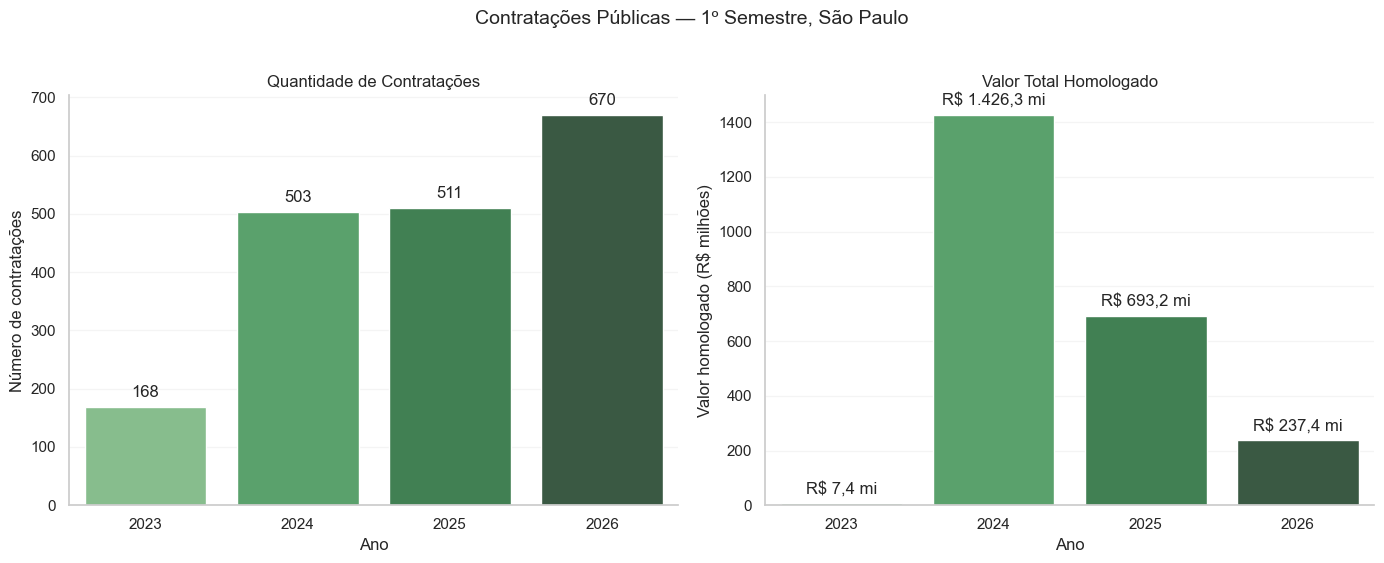

In [19]:
# Figura 1 — Quantidade de contratações + valor total homologado
anos_str = resumo_anual['ano'].astype(str)
paleta_verde = sns.color_palette('Greens_d', n_colors=len(resumo_anual))
paleta_anos = dict(zip(anos_str, paleta_verde))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.barplot(
    data=resumo_anual, x=anos_str, y='Qtd_Contratacoes',
    hue=anos_str, palette=paleta_anos, legend=False, ax=axes[0]
)
axes[0].set_title('Quantidade de Contratações')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Número de contratações')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.2)

for barra in axes[0].patches:
    altura = barra.get_height()
    axes[0].annotate(
        f'{altura:,.0f}'.replace(',', '.'),
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom'
    )

sns.barplot(
    data=resumo_anual, x=anos_str, y='Valor_Homologado_Mi',
    hue=anos_str, palette=paleta_anos, legend=False, ax=axes[1]
)
axes[1].set_title('Valor Total Homologado')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Valor homologado (R$ milhões)')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', alpha=0.2)

for barra in axes[1].patches:
    altura = barra.get_height()
    axes[1].annotate(
        f'R$ {altura:,.1f} mi'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom'
    )

fig.suptitle('Contratações Públicas — 1º Semestre, São Paulo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Bloco 10: Gráfico de linhas: evolução mensal das contratações

O gráfico de linhas detalha a quantidade de contratações mês a mês, de janeiro a junho, para cada ano analisado. Essa visualização complementa a comparação anual ao mostrar como as contratações se distribuíram dentro de cada primeiro semestre. 

Assim, é possível observar concentrações, quedas ou oscilações mensais que poderiam não aparecer em uma comparação baseada apenas nos totais anuais.

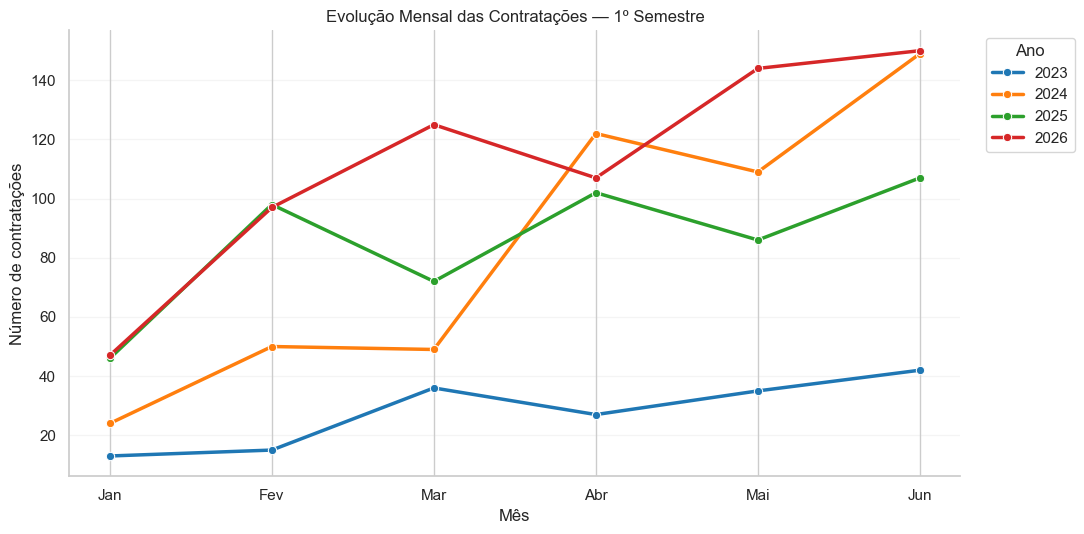

In [23]:
df_mensal = df_analise.copy()
df_mensal['mes'] = df_mensal['dataPublicacaoPncp'].dt.month

resumo_mensal = (
    df_mensal
    .groupby(['ano', 'mes'], as_index=False)
    .agg(Qtd_Contratacoes=('idCompra', 'nunique'))
)

resumo_mensal['ano_str'] = resumo_mensal['ano'].astype(str)
meses = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun'}

fig, ax = plt.subplots(figsize=(11, 5.5))

cores_linhas = sns.color_palette('tab10', n_colors=resumo_mensal['ano'].nunique())

sns.lineplot(
    data=resumo_mensal,
    x='mes', y='Qtd_Contratacoes', hue='ano_str',
    marker='o', linewidth=2.5, palette=cores_linhas, ax=ax
)

ax.set_xticks(range(1, 7))
ax.set_xticklabels([meses[i] for i in range(1, 7)])
ax.set_title('Evolução Mensal das Contratações — 1º Semestre')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de contratações')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.legend(title='Ano', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Conclusão

No projeto foi estruturado uma análise reprodutível da evolução das contratações públicas relacionadas a obras, construção e serviços de engenharia no Estado de São Paulo, considerando o primeiro semestre de 2023 a 2026. A partir dos dados do PNCP, foram realizadas etapas de coleta, normalização, filtragem temática, validação, deduplicação, tratamento de uma observação anômala e construção de métricas e visualizações.

Os resultados apresentados no notebook permitem comparar a quantidade de contratações e os valores homologados entre os anos, além de observar a distribuição mensal das contratações. A análise de sensibilidade também mostra a importância do tratamento de valores atípicos, evitando que uma única observação de grande magnitude domine a interpretação dos indicadores financeiros.

De modo geral, o estudo atende à pergunta norteadora ao fornecer uma visão descritiva da evolução temporal das contratações e das diferenças entre anos eleitorais e não eleitorais. Entretanto, essas diferenças não devem ser interpretadas como evidência de efeito causal das eleições, pois o projeto não utiliza um desenho estatístico destinado a estabelecer causalidade.

Assim, a principal contribuição do trabalho está na organização e no tratamento sistemático dos dados, permitindo uma leitura mais clara, comparável e transparente do comportamento das contratações públicas no período analisado.